In [ ]:
# Correlation Analysis for Tabular_1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Correct relative path (tabular_3 -> tabular_1)
file_path = "../tabular_1/diabetes_012_train.csv"
label_col = "Diabetes_012"

# Load dataset
df_train = pd.read_csv(file_path)

print("Data shape:", df_train.shape)
print("Columns:", list(df_train.columns))


Data shape: (229712, 22)
Columns: ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex', 'GenHlth', 'Age', 'Education', 'Income', 'BMI', 'MentHlth', 'PhysHlth', 'Diabetes_012']


Data shape: (137826, 22)
Columns: ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex', 'GenHlth', 'Age', 'Education', 'Income', 'BMI', 'MentHlth', 'PhysHlth', 'Diabetes_012']

In [15]:
# Compute Pearson correlation with the label
corr_series = df_train.corr(numeric_only=True)[label_col].drop(label_col)

# Sort by absolute correlation value
corr_abs_sorted = corr_series.abs().sort_values(ascending=False)

# Display top 15 correlated features
print("\nTop 15 correlated features with label:")
print(corr_series.reindex(corr_abs_sorted.index[:15]))



Top 15 correlated features with label:
GenHlth                 0.282711
HighBP                  0.259462
BMI                     0.211969
DiffWalk                0.208826
HighChol                0.203577
Age                     0.188817
HeartDiseaseorAttack    0.168979
PhysHlth                0.157783
Income                 -0.147627
Education              -0.107615
PhysActivity           -0.104419
Stroke                  0.098430
CholCheck               0.075469
HvyAlcoholConsump      -0.063512
MentHlth                0.060108
Name: Diabetes_012, dtype: float64


C:\Users\Xushengzhe\AppData\Local\Temp\ipykernel_6400\964891111.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


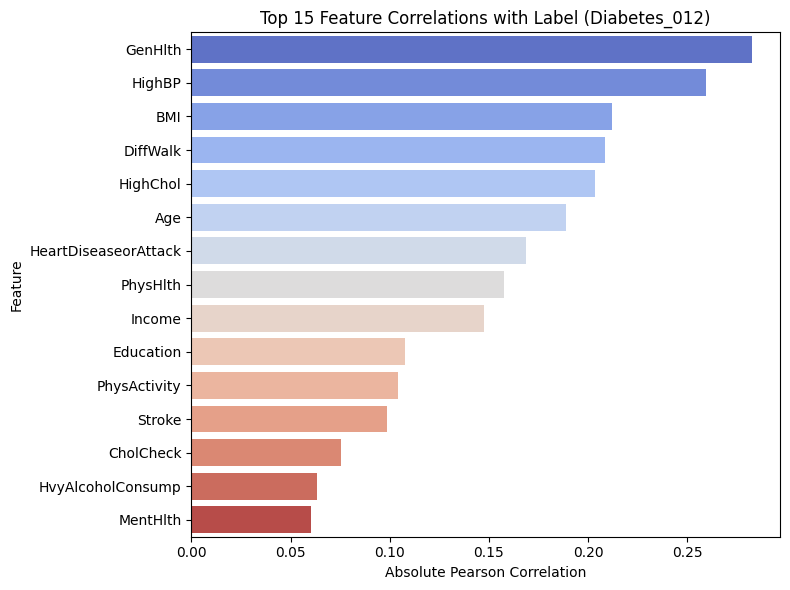

In [16]:
# Visualize top 15 absolute correlations
plt.figure(figsize=(8,6))
sns.barplot(
    x=corr_abs_sorted.values[:15],
    y=corr_abs_sorted.index[:15],
    palette="coolwarm"
)
plt.title("Top 15 Feature Correlations with Label (Diabetes_012)")
plt.xlabel("Absolute Pearson Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [17]:
# Select the final 8 template features and save 
# Prerequisite: corr_abs_sorted is already defined

# Core universal features that are almost always present across datasets
core_features = ["Age", "Sex", "BMI"]

# Take the top 10 features from correlation ranking
top_from_corr = list(corr_abs_sorted.index[:10])

# Merge and remove duplicates (keep order), then trim to 8 features
from collections import OrderedDict
merged = list(OrderedDict.fromkeys(core_features + top_from_corr))
mask_features = merged[:8]

print("Final 8 template features:", mask_features)

# Save the template as CSV and JSON for later alignment
import json
import pandas as pd
from pathlib import Path


out_dir = Path("feature_templates")
out_dir.mkdir(exist_ok=True)

# 1) Save as CSV (one column: feature)
pd.Series(mask_features, name="feature").to_csv(out_dir / "feature_template_v1.csv", index=False)

# 2) Save as JSON (with version, label name, and feature list)
template_meta = {"version": "v1", "label": label_col, "features": mask_features}
(out_dir / "feature_template_v1.json").write_text(json.dumps(template_meta, indent=2), encoding="utf-8")

print("Saved:", out_dir / "feature_template_v1.csv")
print("Saved:", out_dir / "feature_template_v1.json")


Final 8 template features: ['Age', 'Sex', 'BMI', 'GenHlth', 'HighBP', 'DiffWalk', 'HighChol', 'HeartDiseaseorAttack']
Saved: feature_templates\feature_template_v1.csv
Saved: feature_templates\feature_template_v1.json
